# Supply Chain Demand Watch

This notebook identifies which SKUs need attention before a stockout or excess inventory becomes a problem. It uses the same analysis functions as the FastAPI dashboard.

Outline

- Import Libraries
- Load Data

### Import Libraries

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns; sns.set
import warnings

warnings.filterwarnings("ignore")

In [37]:
# Create a copy of the original dataset
RAW_PATH = "../project1_supply_chain_demand (1).csv"

def load_raw(path=RAW_PATH):
    try:
        data = pd.read_csv(path)
        data["date"] = pd.to_datetime(data["date"])
        return data
    except FileNotFoundError:
        print("Error: Raw data file not found. Please check the file path.")
        return pd.DataFrame()

data = load_raw()

### Data Overview and Profiling

In [38]:
data.head()

,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7


In [39]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 4551 entries, 0 to 4550
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   date            4551 non-null   datetime64[us]
 1   sku_id          4551 non-null   str           
 2   category        4551 non-null   str           
 3   units_sold      4461 non-null   float64       
 4   units_received  4551 non-null   int64         
 5   closing_stock   4505 non-null   float64       
 6   lead_time_days  4551 non-null   int64         
dtypes: datetime64[us](1), float64(2), int64(2), str(2)
memory usage: 312.8 KB


In [40]:
#check the number of rows and columns in the dataset
rows, columns = data.shape
print(f"The dataset contains {rows} rows and {columns} columns.")

The dataset contains 4551 rows and 7 columns.


In [41]:
#check for missing values in the dataset
data.isna().sum()

date               0
sku_id             0
category           0
units_sold        90
units_received     0
closing_stock     46
lead_time_days     0
dtype: int64

### Data Cleaning and Preprocessing

In [42]:
# Collapse case-inconsistent category labels
def normalize_category(data):
    data["category"] = data["category"].str.strip().str.title()
    return data

data = normalize_category(data)

In [43]:
#Remove fully-duplicated (sku_id, date) rows. 
def drop_exact_duplicates(data):
    before = len(data)
    data = data.drop_duplicates(subset=["sku_id", "date"], keep="first")
    after = len(data)
    print(f"Dropped {before - after} exact duplicate rows")
    return data

data = drop_exact_duplicates(data)

Dropped 15 exact duplicate rows


In [44]:
#Fill missing values in the units_sold column using linear interpolation within each SKU group.
def fill_missing_units_sold(data):
    data = data.sort_values(["sku_id", "date"])
    data["units_sold_imputed"] = data["units_sold"].isna()
    data["units_sold"] = data.groupby("sku_id")["units_sold"].transform(
        lambda s: s.interpolate(method="linear").round()
    )
    data["units_sold"] = data.groupby("sku_id")["units_sold"].transform(
        lambda s: s.bfill().ffill()
    )
    return data

data = fill_missing_units_sold(data)

In [45]:
# Check if the missing values in the units_sold column have been filled
data.isna().sum()

date                   0
sku_id                 0
category               0
units_sold             0
units_received         0
closing_stock         45
lead_time_days         0
units_sold_imputed     0
dtype: int64

In [46]:
def reconstruct_missing_closing_stock(data):
    data = data.sort_values(["sku_id", "date"]).reset_index(drop=True)
    data["closing_stock_imputed"] = data["closing_stock"].isna()

    for sku, idx in data.groupby("sku_id").groups.items():
        idx = list(idx)
        for i in idx:
            if pd.isna(data.loc[i, "closing_stock"]):
                pos = idx.index(i)
                if pos == 0:
                    # No prior day to reconstruct from -- leave for a fallback pass.
                    continue
                prev_i = idx[pos - 1]
                prev_stock = data.loc[prev_i, "closing_stock"]
                implied = prev_stock - data.loc[i, "units_sold"] + data.loc[i, "units_received"]
                data.loc[i, "closing_stock"] = max(implied, 0)
    return data

data = reconstruct_missing_closing_stock(data)

In [47]:
NEW_SKUS = ["SKU-2000", "SKU-2001", "SKU-2002"]


def fix_new_sku_lead_time(data):
    """For established SKUs, lead_time_days is a single fixed value (verified).
    For the 3 new SKUs, it changes almost daily across the same value set used
    elsewhere -- unset/placeholder data, not real values. Replace it with the
    category-level median lead time from established SKUs, and flag the rows
    so this assumption is visible downstream (README, UI, risk confidence)."""
    data["lead_time_assumed"] = False

    established = data[~data["sku_id"].isin(NEW_SKUS)]
    cat_median_lead = (
        established.groupby(["category", "sku_id"])["lead_time_days"]
        .first()
        .groupby("category")
        .median()
    )

    for sku in NEW_SKUS:
        mask = data["sku_id"] == sku
        if not mask.any():
            continue
        cat = data.loc[mask, "category"].iloc[0]
        data.loc[mask, "lead_time_days"] = int(cat_median_lead[cat])
        data.loc[mask, "lead_time_assumed"] = True

    return data

data = fix_new_sku_lead_time(data)

In [48]:
def check_date_gaps(data):
    """For each SKU, compare actual row count to expected (first date -> last date, daily)."""
    report = []
    for sku, g in data.groupby("sku_id"):
        g = g.sort_values("date")
        expected_days = (g["date"].max() - g["date"].min()).days + 1
        actual_rows = len(g)
        report.append({
            "sku_id": sku,
            "first_date": g["date"].min(),
            "last_date": g["date"].max(),
            "expected_days": expected_days,
            "actual_rows": actual_rows,
            "missing_rows": expected_days - actual_rows,
        })
    return pd.DataFrame(report).sort_values("missing_rows", ascending=False)
gaps = check_date_gaps(data)

In [ ]:
data = load_raw()
data = normalize_category(data)
df = drop_exact_duplicates(data)

gaps = check_date_gaps(data)  # sanity check -- should show 0 missing_rows everywhere

data = fill_missing_units_sold(data)
data = reconstruct_missing_closing_stock(data)
data = fix_new_sku_lead_time(data)

In [49]:
data.head()

,date,sku_id,category,units_sold,units_received,closing_stock,lead_time_days,units_sold_imputed,closing_stock_imputed,lead_time_assumed
0,2026-01-01,SKU-1000,Snacks,110.0,0,403.0,7,False,False,False
1,2026-01-02,SKU-1000,Snacks,278.0,0,125.0,7,False,False,False
2,2026-01-03,SKU-1000,Snacks,121.0,903,907.0,7,False,False,False
3,2026-01-04,SKU-1000,Snacks,75.0,0,832.0,7,False,False,False
4,2026-01-05,SKU-1000,Snacks,71.0,0,761.0,7,False,False,False


### Exploratory Data Analysis (EDA)

In [50]:
overall = df["units_sold"].describe()
by_category = df.groupby("category")["units_sold"].agg(["mean", "std", "min", "max"])
print(overall)
by_category

count    4461.000000
mean      296.980722
std       157.044557
min        14.000000
25%       184.000000
50%       266.000000
75%       403.000000
max      1366.000000
Name: units_sold, dtype: float64


,mean,std,min,max
category,,,,
BEVERAGES,346.750000,141.291745,138.0,538.0
Beverages,324.641935,125.022797,35.0,1068.0
FLOUR,232.000000,35.355339,207.0,257.0
Flour,256.435424,76.703636,36.0,682.0
PASTA,94.000000,NaN,94.0,94.0
Pasta,339.321580,183.345367,34.0,1366.0
SNACKS,151.000000,101.715289,88.0,303.0
SUGAR,258.500000,198.901148,55.0,449.0
Snacks,256.897292,154.134329,14.0,851.0


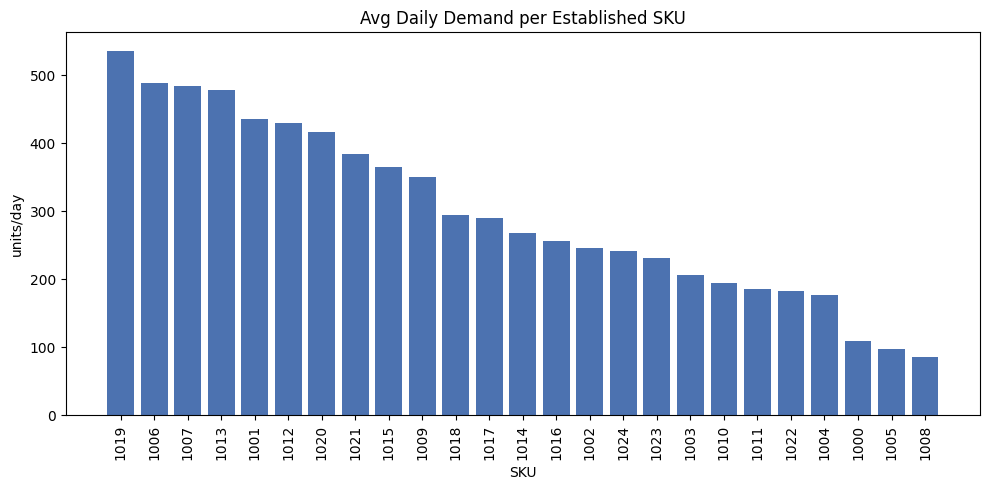

In [51]:
# Avg daily demand per established SKU -- shows ~5x scale spread across SKUs,
# which is why risk thresholds need to be ratio-based, not fixed unit cutoffs.
established = df[~df["sku_id"].isin(NEW_SKUS)]
avg_demand = established.groupby("sku_id")["units_sold"].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(avg_demand.index.str.replace("SKU-", ""), avg_demand.values, color="#4C72B0")
ax.set_title("Avg Daily Demand per Established SKU")
ax.set_xlabel("SKU"); ax.set_ylabel("units/day")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Weekly total demand -- checks for growth/decline trend over the 6 months.
est = established.copy()
est["week"] = est["date"].dt.isocalendar().week
weekly = est.groupby("week")["units_sold"].sum()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(weekly.index, weekly.values, marker="o", color="#55A868")
ax.set_title("Weekly Total Demand — Established SKUs")
ax.set_xlabel("ISO week"); ax.set_ylabel("total units sold")
plt.tight_layout()
plt.show()

# Flat aside from partial first/last weeks -- no meaningful trend.
weekly

### Machine Learning Model Building

In [ ]:
from sklearn.model_selection import train_test_split